# Constrained sampling on the ball: aiming the skew field

Target restricted to the Euclidean ball

$$K=\{x\in\mathbb R^3:\ \lVert x\rVert_2\le R\},\qquad
\pi(x)\;\propto\;e^{-U(x)}\,\mathbf 1_K(x),$$

with the same two targets as before, now comparing **four** schemes: $J=0$, the constant skew $J_a$, the
cross-product field $J_s(x)w=s\,(x\times w)$, and an **alignable** admissible field.

## What changed, and why

The previous run reported $W_1$ at 1500 iterations. At that horizon neither scheme has converged — $J=0$
was still at $0.103$ against a floor of $0.0134$, and still falling by 20% every 300 iterations. So the
table was a snapshot of a race in progress, and read as though it were a stationary comparison. Every
number here is taken at a horizon where $J=0$ actually reaches the floor (8000 iterations), and the two
questions are separated:

* **how fast** — $\tau$, the iteration after which $W_1$ stays below twice the floor;
* **how accurate** — $W_1$ averaged over the last 500 iterations, and the mass deposited on $\partial K$.

Both are reported over **8 replicas with bootstrap intervals**, because a single-seed $\tau$ turned out to
be unusable: it is a last-crossing statistic, and one late noise excursion moves it by a factor of three.

## The field you cannot aim

The cross-product field $J_s(x)w=s\,(x\times w)$ rotates about $x$ itself. That makes it automatically
tangential — $J_s(x)x=s\,(x\times x)=0$ — and divergence-free, which is why the earlier notebook needed no
correction term. But it also means **there is no free axis**: the rotation plane is whatever is
perpendicular to the current position, not whatever the target actually mixes slowly in.

The generalisation keeps admissibility and buys back the freedom. For a constant antisymmetric $A$,

$$J_s(x)\;=\;\frac{s}{R^2}\Bigl[\lVert x\rVert^2A+x\,(Ax)^{\!\top}-(Ax)\,x^{\!\top}\Bigr].$$

It is antisymmetric for every $x$; it annihilates $x$ identically, so $J_s(x)\nu(x)=0$ on $\partial K$ by
construction; and $A$ is free, so the rotation can be put in the plane of the two largest-variance
eigenvectors of $\Sigma$ — the directions Langevin crawls along. The price is that it is **not**
divergence-free:

$$(\nabla\!\cdot J_s)(x)\;=\;-\frac{s}{R^2}\,(d-2)\,Ax,$$

so the anchored dynamics must carry the correction term $+\,e^{\Delta}\nabla\!\cdot J$ that the
cross-product field let us drop. That is checked against autograd below.

| | $J(x)$ | $\nabla\!\cdot J$ | $J\nu$ on $\partial K$ | aimable |
|---|---|---|---|---|
| `none` | $0$ | $0$ | $0$ | — |
| `const` | $sJ_a$ | $0$ | $\neq0$ — **violates the wall condition** | no |
| `cross` | $s\,[x]_\times$ | $0$ | $0$ | **no** |
| `aligned` | $\tfrac{s}{R^2}[r^2A+x(Ax)^{\!\top}-(Ax)x^{\!\top}]$ | $-\tfrac{s}{R^2}(d-2)Ax$ | $0$ | **yes** |

In [1]:
%matplotlib inline
import math
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from matplotlib.patches import Circle
from scipy.stats import ks_2samp, wasserstein_distance

torch.set_default_dtype(torch.float64)
os.makedirs("figures", exist_ok=True)
sns.set_theme(style="whitegrid", context="notebook")

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
R        = 1.5          # K = {||x||_2 <= R}
N        = 5000         # walkers per replica
REPLICAS = 8            # independent replicas, run as one batched ensemble
MAXIT    = 8000         # long enough that J = 0 reaches the floor; 1500 was not
eta      = 5e-4
delta    = 0.1          # anchor smoothing
x_start  = 0.5
SEED     = 106
TRACK    = 25

SCALES = [0.5, 1.0, 2.0]
RHO    = 0.6

def make_L(dim, scales, rho):
    Dm = np.diag(scales)
    Cm = np.full((dim, dim), rho); np.fill_diagonal(Cm, 1.0)
    return np.linalg.cholesky(Dm @ Cm @ Dm)

L3   = make_L(d, SCALES, RHO)
SIG  = L3 @ L3.T
Minv = torch.tensor(np.linalg.inv(L3))
EVAL, EVEC = np.linalg.eigh(SIG)
print("Sigma =\n", np.round(SIG, 3))
print("eigenvalues", np.round(EVAL, 3), "  condition number {:.1f}".format(EVAL[-1] / EVAL[0]))
print("slowest-mixing plane = the two LARGEST-variance eigenvectors")
print("  so the rotation axis is the smallest-variance one:", np.round(EVEC[:, 0], 3))

Sigma =
 [[0.25 0.3  0.6 ]
 [0.3  1.   1.2 ]
 [0.6  1.2  4.  ]]
eigenvalues [0.131 0.595 4.525]   condition number 34.6
slowest-mixing plane = the two LARGEST-variance eigenvectors
  so the rotation axis is the smallest-variance one: [ 0.971 -0.223 -0.082]


## The four fields, and the two conditions they have to meet

In [3]:
def J_const_mat(dim, a):
    return (torch.diag(a * torch.ones(dim - 1), diagonal=1)
            + torch.diag(-a * torch.ones(dim - 1), diagonal=-1))


def skew_from_plane(u, v):
    """A = u v^T - v u^T, the generator of rotation in span(u, v), unit spectral norm."""
    A = np.outer(np.asarray(u, float), np.asarray(v, float))
    A = A - A.T
    return torch.tensor(A / np.linalg.norm(A, 2))


A_SLOW = skew_from_plane(EVEC[:, 2], EVEC[:, 1])   # the two largest variances -> slowest mixing
A_FAST = skew_from_plane(EVEC[:, 0], EVEC[:, 1])   # the two smallest variances
A_TRI  = J_const_mat(d, 1.0) / torch.linalg.matrix_norm(J_const_mat(d, 1.0), ord=2)


def apply_field(field, x, g, s, A=None):
    """J(x) g, row-wise."""
    if field == "none":
        return torch.zeros_like(g)
    if field == "const":
        return g @ J_const_mat(d, s).T
    if field == "cross":
        return s * torch.cross(x, g, dim=1)
    c = s / R ** 2                                  # aligned
    Ax, Ag = x @ A.T, g @ A.T
    r2 = (x * x).sum(1, keepdim=True)
    xg = (x * g).sum(1, keepdim=True)
    Axg = (Ax * g).sum(1, keepdim=True)
    return c * (r2 * Ag + Axg * x - xg * Ax)


def div_field(field, x, s, A=None):
    """div J, in closed form.  Only the aligned field has a non-zero one."""
    if field != "aligned":
        return torch.zeros_like(x)
    return -(s / R ** 2) * (d - 2) * (x @ A.T)


def autograd_div(field, x, s, A=None):
    """(div J)_i = sum_j d_j J_ij, by autograd, with no knowledge of the closed form."""
    n = x.shape[0]
    x = x.detach().clone().requires_grad_(True)
    out = torch.zeros(n, d)
    eye = torch.eye(d)
    for j in range(d):
        col = apply_field(field, x, eye[j].expand(n, d), s, A)
        if not col.requires_grad:
            continue
        for i in range(d):
            gi = torch.autograd.grad(col[:, i].sum(), x, retain_graph=True, allow_unused=True)[0]
            if gi is not None:
                out[:, i] += gi[:, j]
    return out.detach()


S_CHECK = 8.0
g = torch.Generator().manual_seed(0)
xs = torch.randn(200, d, generator=g)
wall = R * xs / xs.norm(dim=1, keepdim=True)
nu = wall / wall.norm(dim=1, keepdim=True)
rows = []
for field, A, name in [("const", None, "constant $J_a$"), ("cross", None, "cross-product"),
                       ("aligned", A_SLOW, "aligned (slow plane)")]:
    Jm = torch.stack([torch.stack([apply_field(field, p.expand(d, d), torch.eye(d), S_CHECK, A)[k]
                                   for k in range(d)]).T for p in xs[:6]])
    rows.append({
        "field": name,
        "max |J + J^T|": "{:.1e}".format(float((Jm + Jm.transpose(1, 2)).abs().max())),
        "|div autograd - closed|": "{:.1e}".format(float(
            (autograd_div(field, xs[:6], S_CHECK, A) - div_field(field, xs[:6], S_CHECK, A)).abs().max())),
        "mean ||div J|| on dK": round(float(div_field(field, wall, S_CHECK, A).norm(dim=1).mean()), 3),
        "mean ||J nu|| on dK": "{:.2e}".format(float(
            apply_field(field, wall, nu, S_CHECK, A).norm(dim=1).mean())),
        "mean ||J||_2 on dK": round(float(np.mean([
            float(torch.linalg.matrix_norm(
                torch.stack([apply_field(field, p.expand(d, d), torch.eye(d), S_CHECK, A)[k]
                             for k in range(d)]).T, ord=2)) for p in wall[:40]])), 2)})
print("at s = {:g}:".format(S_CHECK))
pd.DataFrame(rows).set_index("field")

at s = 8:


,max |J + J^T|,|div autograd - closed|,mean ||div J|| on dK,mean ||J nu|| on dK,mean ||J||_2 on dK
field,,,,,
constant $J_a$,0.0e+00,0.0e+00,0.000,8.89e+00,11.31
cross-product,0.0e+00,0.0e+00,0.000,3.43e-16,12.00
aligned (slow plane),4.4e-16,8.9e-16,4.162,6.95e-16,4.31


Read the last two columns together. `cross` and `aligned` both put **zero** flux through the wall, which
is what admissibility means; `const` puts $O(s)$ through it. And the three fields have comparable operator
norm on $\partial K$, so a comparison at equal $s$ is a fair one.

The `aligned` field is the only one with a non-zero divergence, and the closed form
$-\tfrac{s}{R^2}(d-2)Ax$ agrees with autograd to machine precision. Carrying that term is what makes it
admissible; dropping it would sample the wrong law.

In [4]:
# -----------------------------
# Targets, and exact reference samples by rejection
# -----------------------------
def build_target(kind):
    if kind == "ell":
        @torch.no_grad()
        def U(x):  return torch.norm(x @ Minv.T, dim=1)
        @torch.no_grad()
        def U0(x): return torch.sqrt(torch.sum((x @ Minv.T) ** 2, dim=1) + delta ** 2)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(torch.sum(y ** 2, dim=1, keepdim=True) + delta ** 2)) @ Minv
    else:
        @torch.no_grad()
        def U(x):  return torch.sum(torch.abs(x @ Minv.T), dim=1)
        @torch.no_grad()
        def U0(x): return torch.sum(torch.sqrt((x @ Minv.T) ** 2 + delta ** 2), dim=1)
        @torch.no_grad()
        def gU0(x):
            y = x @ Minv.T
            return (y / torch.sqrt(y ** 2 + delta ** 2)) @ Minv
    return U, U0, gU0


def sample_target(kind, n, rng):
    """Draw from the unconstrained target, keep what lands in K."""
    out = []
    while len(out) < n:
        if kind == "ell":
            r = rng.gamma(d, 1.0, n)
            u = rng.normal(size=(n, d)); u /= np.linalg.norm(u, axis=1, keepdims=True)
            y = r[:, None] * u
        else:
            y = rng.laplace(0.0, 1.0, size=(n, d))
        z = y @ L3.T
        out.extend(z[np.linalg.norm(z, axis=1) <= R].tolist())
    return np.array(out[:n])


@torch.no_grad()
def proj_ball(x):
    nrm = torch.norm(x, dim=1, keepdim=True)
    return x * torch.clamp(R / nrm, max=1.0)


def on_boundary(X):
    return float(np.mean(np.linalg.norm(X, axis=1) > 0.999 * R))


def w1_floor(ref, kind, rng, reps=4):
    """W1 between independent draws of the same size: the resolution limit."""
    return float(np.mean([[wasserstein_distance(ref[:, i], sample_target(kind, len(ref), rng)[:, i])
                           for i in range(d)] for _ in range(reps)]))

## Protocol

Replicas are run as one batched $(S\!\cdot\!N,d)$ ensemble: the blocks stay independent because the noise
is i.i.d. across the batch, and they start from the same point, which is statistically the same as $S$
separate seeds but much cheaper.

$\tau$ is the iteration after which a replica's $W_1$ stays below twice the floor. It is a last-crossing
statistic, so it is sensitive to a single late excursion — which is exactly why it is reported as a mean
over replicas with a bootstrap interval rather than as one number.

In [5]:
@torch.no_grad()
def run_replicas(kind_target, field, s, A=None, ref=None, S=REPLICAS,
                 n_steps=MAXIT, seed=SEED, eta=eta):
    """Returns (iters, W1[S, ntrack], final sample [S, N, d])."""
    U, U0, gU0 = build_target(kind_target)
    torch.manual_seed(seed)
    x = proj_ball(torch.full((S * N, d), x_start))
    it, W = [], []
    for k in range(n_steps):
        Delta = U(x) - U0(x)
        eD = torch.exp(Delta).unsqueeze(1)
        g = gU0(x) * eD
        drift = g + apply_field(field, x, g, s, A) - eD * div_field(field, x, s, A)
        x = proj_ball(x - eta * drift
                      + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x))
        if (k + 1) % TRACK == 0:
            xn = x.numpy().reshape(S, N, d)
            it.append(k + 1)
            W.append([np.mean([wasserstein_distance(ref[:, i], xn[r, :, i]) for i in range(d)])
                      for r in range(S)])
    return np.array(it), np.array(W).T, x.numpy().reshape(S, N, d)


def tau_one(it, w, thr):
    bad = np.where(w > thr)[0]
    j = 0 if len(bad) == 0 else bad[-1] + 1
    return float(it[j]) if j < len(it) else np.nan


def boot(v, B=4000, seed=0):
    """Percentile bootstrap over replicas.  A replica that never reached the threshold
    contributes NaN; if none did, the answer is 'never' rather than a number."""
    v = np.asarray(v, float)
    if not np.any(np.isfinite(v)):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = [np.nanmean(x) for x in (v[rng.integers(0, len(v), len(v))] for _ in range(B))
             if np.any(np.isfinite(x))]
    return np.nanmean(v), float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5))


def boot_speedup(base, cur, B=4000, seed=1):
    base, cur = np.asarray(base, float), np.asarray(cur, float)
    if not (np.any(np.isfinite(base)) and np.any(np.isfinite(cur))):
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(B):
        a, b = base[rng.integers(0, len(base), len(base))], cur[rng.integers(0, len(cur), len(cur))]
        if np.any(np.isfinite(a)) and np.any(np.isfinite(b)):
            draws.append(np.nanmean(a) / np.nanmean(b))
    return (np.nanmean(base) / np.nanmean(cur),
            float(np.percentile(draws, 2.5)), float(np.percentile(draws, 97.5)))


def fmt_tau(t):
    return "never" if not np.isfinite(t[0]) else "{:.0f} [{:.0f}, {:.0f}]".format(*t)


def fmt_speed(sp, n_never=0):
    if not np.isfinite(sp[0]):
        return "never reaches it"
    tag = "  ({} of {} replicas never)".format(n_never, REPLICAS) if n_never else ""
    return "{:.2f}x [{:.2f}, {:.2f}]".format(*sp) + tag

In [6]:
TARGETS = {"ell": "Target A: elliptical Laplace on K", "l1": "Target B: correlated $\\ell_1$ Laplace on K"}

GRID = ([("none", 0.0, None, "J = 0"),
         ("const", 8.0, None, "constant $J_a$, s=8")]
        + [("cross", s, None, "cross-product, s={:g}".format(s)) for s in (4, 8, 16)]
        + [("aligned", s, A_SLOW, "aligned slow, s={:g}".format(s)) for s in (8, 16, 32, 64)]
        + [("aligned", 16.0, A_FAST, "aligned fast, s=16"),
           ("aligned", 16.0, A_TRI, "aligned tridiag, s=16")])

rng = np.random.default_rng(SEED)
refs, floors, RES = {}, {}, {}
for kind in TARGETS:
    refs[kind] = sample_target(kind, N, rng)
    floors[kind] = w1_floor(refs[kind], kind, rng)
    RES[kind] = {}
    print("\n### {}   floor {:.4f}   target boundary mass {:.4f}".format(
        kind, floors[kind], on_boundary(refs[kind])), flush=True)
    for field, s, A, lab in GRID:
        t0 = time.time()
        it, W, X = run_replicas(kind, field, s, A=A, ref=refs[kind])
        taus = np.array([tau_one(it, w, 2 * floors[kind]) for w in W])
        RES[kind][lab] = {"it": it, "W": W, "X": X, "taus": taus,
                          "stat": W[:, -20:].mean(axis=1),
                          "bd": on_boundary(X.reshape(-1, d)), "field": field, "s": s}
        print("   {:<26} {:5.0f}s".format(lab.replace("$", ""), time.time() - t0), flush=True)


### ell   floor 0.0136   target boundary mass 0.0022


   J = 0                         56s


   constant J_a, s=8             57s


   cross-product, s=4            58s


   cross-product, s=8            58s


...

   aligned slow, s=16            72s


   aligned slow, s=32            74s


   aligned slow, s=64            74s


   aligned fast, s=16            70s


   aligned tridiag, s=16         75s


## Experiment 1 — does aiming the rotation matter?

Same field, same strength, three different rotation planes: the two largest-variance eigenvectors (the
directions the sampler crawls along), the two smallest, and an arbitrary tridiagonal generator.

In [7]:
rows = []
for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    for lab in ["aligned slow, s=16", "aligned fast, s=16", "aligned tridiag, s=16"]:
        r = RES[kind][lab]
        tm, tlo, thi = boot(r["taus"])
        sp = boot_speedup(base, r["taus"])
        rows.append({"target": kind, "rotation plane": lab.split(",")[0].replace("aligned ", ""),
                     "tau": fmt_tau((tm, tlo, thi)),
                     "speed-up vs J = 0": fmt_speed(sp, int(np.sum(~np.isfinite(r["taus"]))))})
display(pd.DataFrame(rows).set_index(["target", "rotation plane"]))
print("J = 0 baseline tau: " + ", ".join(
    "{} {:.0f}".format(k, np.nanmean(RES[k]["J = 0"]["taus"])) for k in TARGETS))

tau   speed-up vs J = 0
target rotation plane                                       
ell    slow            1809 [1600, 2106]  2.12x [1.79, 2.44]
       fast            3681 [3484, 3897]  1.04x [0.96, 1.13]
       tridiag         2950 [2809, 3094]  1.30x [1.21, 1.40]
l1     slow            1494 [1447, 1550]  2.81x [2.68, 2.94]
       fast            3684 [3528, 3866]  1.14x [1.08, 1.20]
       tridiag         3144 [2984, 3288]  1.34x [1.26, 1.42]

J = 0 baseline tau: ell 3831, l1 4200


## Experiment 2 — strength sweep, for a field you can aim and one you cannot

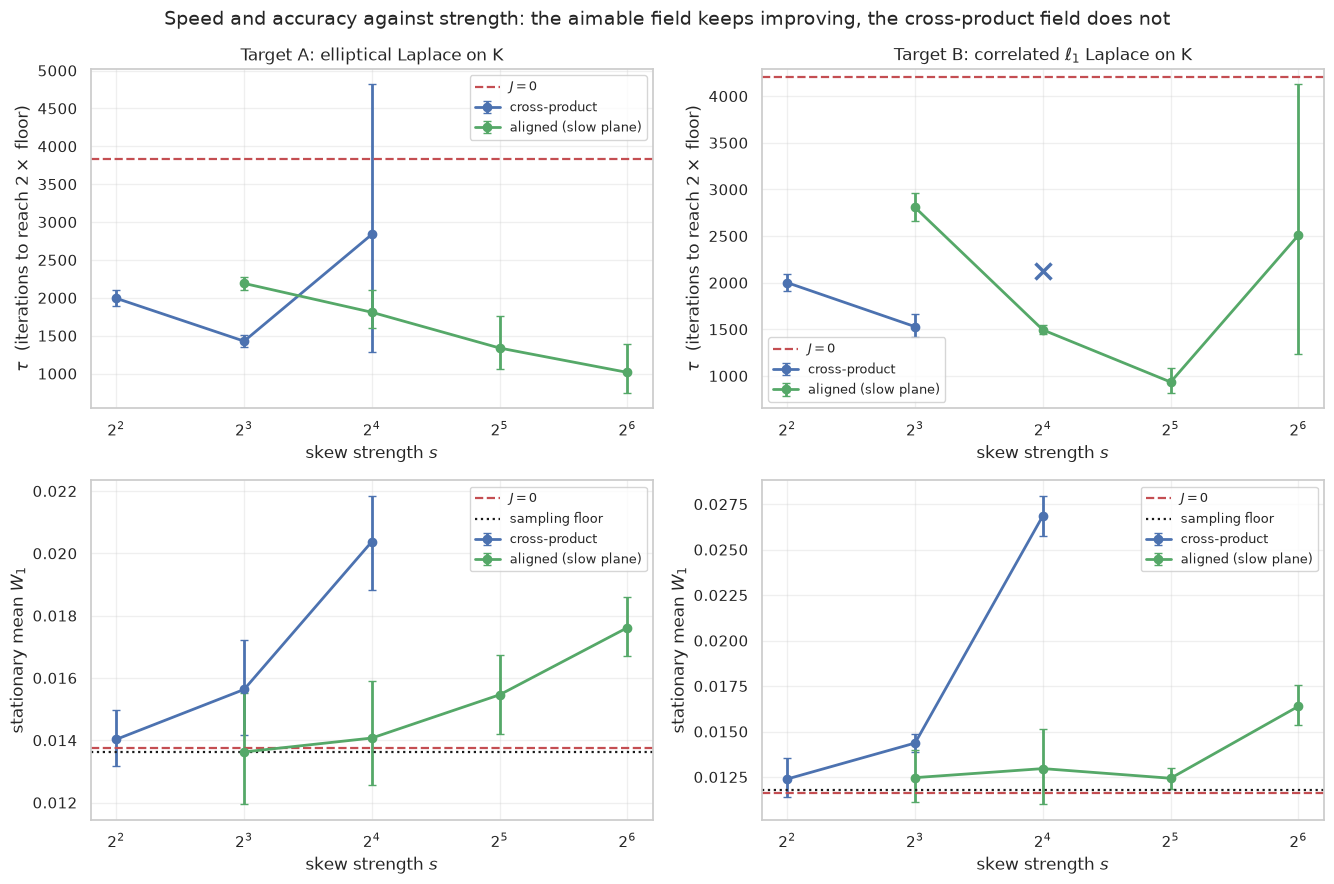

tau            speed-up  \
target field                s                                           
ell    cross-product        4   1994 [1891, 2109]  1.92x [1.78, 2.09]   
                            8   1428 [1356, 1506]  2.68x [2.49, 2.91]   
                            16  2838 [1284, 4820]  1.35x [0.78, 2.93]   
       aligned (slow plane) 8   2191 [2109, 2275]  1.75x [1.64, 1.88]   
                            16  1809 [1600, 2106]  2.12x [1.79, 2.44]   
                            32  1338 [1062, 1759]  2.86x [2.15, 3.66]   
                            64   1016 [750, 1394]  3.77x [2.71, 5.14]   
l1     cross-product        4   2000 [1909, 2094]  2.10x [1.99, 2.22]   
                            8   1528 [1416, 1669]  2.75x [2.50, 2.99]   
                            16              never    never reaches it   
       aligned (slow plane) 8   2806 [2662, 2956]  1.50x [1.41, 1.59]   
                            16  1494 [1447, 1550]  2.81x [2.68, 2.94]   
                            32    934 [822, 1081]  4.49x [3.85, 5.14]   
                            64  2509 [1234, 4128]  1.67x [1.02, 3.44]   

                                          stationary W1  boundary  
target field                s                                      
ell    cross-product        4   0.0140 [0.0132, 0.0150]     0.027  
                            8   0.0156 [0.0142, 0.0172]     0.027  
                            16  0.0204 [0.0188, 0.0218]     0.028  
       aligned (slow plane) 8   0.0136 [0.0119, 0.0155]     0.026  
                            16  0.0141 [0.0126, 0.0159]     0.026  
                            32  0.0155 [0.0142, 0.0167]     0.027  
                            64  0.0176 [0.0167, 0.0186]     0.027  
l1     cross-product        4   0.0124 [0.0114, 0.0135]     0.021  
                            8   0.0144 [0.0139, 0.0149]     0.022  
                            16  0.0269 [0.0258, 0.0280]     0.026  
       aligned (slow plane) 8   0.0125 [0.0111, 0.0140]     0.021  
                            16  0.0130 [0.0110, 0.0152]     0.021  
                            32  0.0124 [0.0118, 0.0130]     0.021  
                            64  0.0164 [0.0154, 0.0175]     0.023

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))
sweep_rows = []
for col, kind in enumerate(TARGETS):
    base = RES[kind]["J = 0"]["taus"]
    for name, labs, c in [("cross-product", ["cross-product, s={:g}".format(s) for s in (4, 8, 16)], "#4C72B0"),
                          ("aligned (slow plane)", ["aligned slow, s={:g}".format(s) for s in (8, 16, 32, 64)], "#55A868")]:
        ss = [RES[kind][l]["s"] for l in labs]
        tm = [boot(RES[kind][l]["taus"]) for l in labs]
        st = [boot(RES[kind][l]["stat"]) for l in labs]
        ok = [i for i, v in enumerate(tm) if np.isfinite(v[0])]
        axes[0, col].errorbar([ss[i] for i in ok], [tm[i][0] for i in ok],
                              yerr=[[tm[i][0] - tm[i][1] for i in ok],
                                    [tm[i][2] - tm[i][0] for i in ok]],
                              fmt="o-", color=c, capsize=3, linewidth=2, label=name)
        for i, v in enumerate(tm):                        # mark "never converged"
            if not np.isfinite(v[0]):
                axes[0, col].plot(ss[i], axes[0, col].get_ylim()[1], "x", color=c,
                                  markersize=11, markeredgewidth=2.5)
        axes[1, col].errorbar(ss, [v[0] for v in st],
                              yerr=[[v[0] - v[1] for v in st], [v[2] - v[0] for v in st]],
                              fmt="o-", color=c, capsize=3, linewidth=2, label=name)
        for l, t, s_ in zip(labs, tm, st):
            sweep_rows.append({"target": kind, "field": name, "s": RES[kind][l]["s"],
                               "tau": fmt_tau(t),
                               "speed-up": fmt_speed(boot_speedup(base, RES[kind][l]["taus"]),
                                                     int(np.sum(~np.isfinite(RES[kind][l]["taus"])))),
                               "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*s_),
                               "boundary": round(RES[kind][l]["bd"], 3)})
    b = boot(RES[kind]["J = 0"]["taus"])
    axes[0, col].axhline(b[0], color="#C44E52", linestyle="--", linewidth=1.6, label="$J = 0$")
    sb = boot(RES[kind]["J = 0"]["stat"])
    axes[1, col].axhline(sb[0], color="#C44E52", linestyle="--", linewidth=1.6, label="$J = 0$")
    axes[1, col].axhline(floors[kind], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    axes[0, col].set_title(TARGETS[kind], fontsize=12)
    axes[0, col].set_ylabel(r"$\tau$  (iterations to reach $2\times$ floor)", fontsize=12)
    axes[1, col].set_ylabel(r"stationary mean $W_1$", fontsize=12)
    for r in (0, 1):
        axes[r, col].set_xscale("log", base=2)
        axes[r, col].set_xlabel("skew strength $s$", fontsize=12)
        axes[r, col].grid(alpha=0.3)
        axes[r, col].legend(fontsize=9)
fig.suptitle("Speed and accuracy against strength: the aimable field keeps improving, "
             "the cross-product field does not", fontsize=14)
plt.tight_layout()
plt.savefig("figures/ball_sweep.pdf", dpi=300, bbox_inches="tight")
plt.show()
display(pd.DataFrame(sweep_rows).set_index(["target", "field", "s"]))

## Experiment 3 — head to head

In [9]:
HEAD = ["J = 0", "constant $J_a$, s=8", "cross-product, s=8", "aligned slow, s=32"]
COL = {"J = 0": "#C44E52", "constant $J_a$, s=8": "#8172B2",
       "cross-product, s=8": "#4C72B0", "aligned slow, s=32": "#55A868"}

for kind in TARGETS:
    base = RES[kind]["J = 0"]["taus"]
    rows = []
    for lab in HEAD:
        r = RES[kind][lab]
        tm = boot(r["taus"])
        st = boot(r["stat"])
        ks = np.mean([max(ks_2samp(refs[kind][:, i], r["X"][j, :, i]).statistic for i in range(d))
                      for j in range(REPLICAS)])
        rows.append({"scheme": lab.replace("$", ""),
                     "tau": fmt_tau(tm),
                     "speed-up": "--" if lab == "J = 0" else
                                 fmt_speed(boot_speedup(base, r["taus"]),
                                           int(np.sum(~np.isfinite(r["taus"])))),
                     "stationary W1": "{:.4f} [{:.4f}, {:.4f}]".format(*st),
                     "max KS": round(float(ks), 4),
                     "mass on dK": "{:.2%}".format(r["bd"])})
    rows.append({"scheme": "reference (truth)", "tau": "--", "speed-up": "--",
                 "stationary W1": "{:.4f}".format(floors[kind]), "max KS": 0.0,
                 "mass on dK": "{:.2%}".format(on_boundary(refs[kind]))})
    print("\n### {}   floor {:.4f}".format(TARGETS[kind], floors[kind]))
    display(pd.DataFrame(rows).set_index("scheme"))


### Target A: elliptical Laplace on K   floor 0.0136


,tau,speed-up,stationary W1,max KS,mass on dK
scheme,,,,,
J = 0,"3831 [3634, 4075]",--,"0.0137 [0.0122, 0.0155]",0.0204,2.62%
"constant J_a, s=8",never,never reaches it,"0.0463 [0.0458, 0.0470]",0.0558,4.17%
"cross-product, s=8","1428 [1356, 1506]","2.68x [2.49, 2.91]","0.0156 [0.0142, 0.0172]",0.0243,2.68%
"aligned slow, s=32","1338 [1062, 1759]","2.86x [2.15, 3.66]","0.0155 [0.0142, 0.0167]",0.0225,2.65%
reference (truth),--,--,0.0136,0.0000,0.22%



### Target B: correlated $\ell_1$ Laplace on K   floor 0.0118


,tau,speed-up,stationary W1,max KS,mass on dK
scheme,,,,,
J = 0,"4200 [4069, 4341]",--,"0.0116 [0.0104, 0.0128]",0.0188,2.09%
"constant J_a, s=8",never,never reaches it,"0.0485 [0.0478, 0.0494]",0.0548,3.91%
"cross-product, s=8","1528 [1416, 1669]","2.75x [2.50, 2.99]","0.0144 [0.0139, 0.0149]",0.0231,2.17%
"aligned slow, s=32","934 [822, 1081]","4.49x [3.85, 5.14]","0.0124 [0.0118, 0.0130]",0.0208,2.08%
reference (truth),--,--,0.0118,0.0000,0.08%


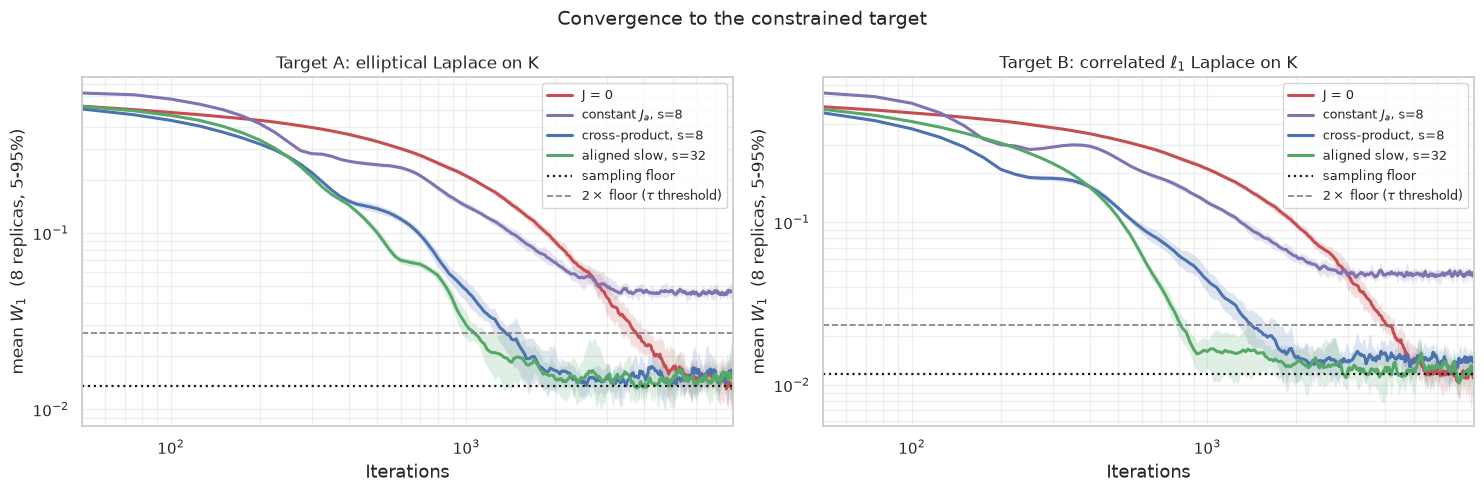

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, kind in zip(axes, TARGETS):
    for lab in HEAD:
        r = RES[kind][lab]
        m = r["W"].mean(axis=0)
        lo, hi = np.percentile(r["W"], 5, axis=0), np.percentile(r["W"], 95, axis=0)
        ax.plot(r["it"], m, linewidth=2.2, color=COL[lab], label=lab)
        ax.fill_between(r["it"], lo, hi, color=COL[lab], alpha=0.18, linewidth=0)
    ax.axhline(floors[kind], color="k", linestyle=":", linewidth=1.6, label="sampling floor")
    ax.axhline(2 * floors[kind], color="0.5", linestyle="--", linewidth=1.2,
               label=r"$2\times$ floor ($\tau$ threshold)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlim(50, MAXIT)
    ax.set_xlabel("Iterations", fontsize=13)
    ax.set_ylabel(r"mean $W_1$  ({} replicas, 5-95%)".format(REPLICAS), fontsize=12)
    ax.set_title(TARGETS[kind], fontsize=12)
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)
fig.suptitle("Convergence to the constrained target", fontsize=14)
plt.tight_layout()
plt.savefig("figures/ball_w1.pdf", dpi=300, bbox_inches="tight")
plt.show()

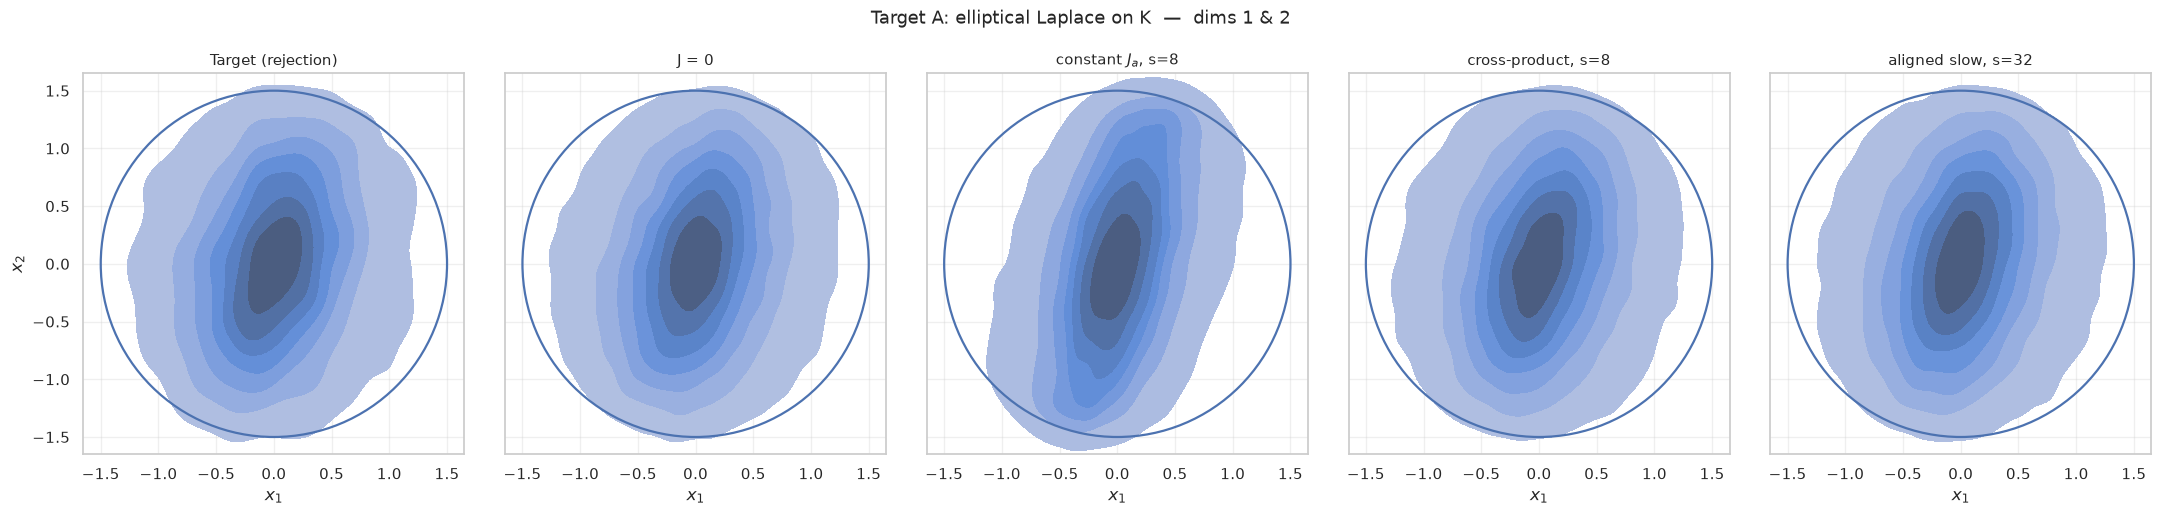

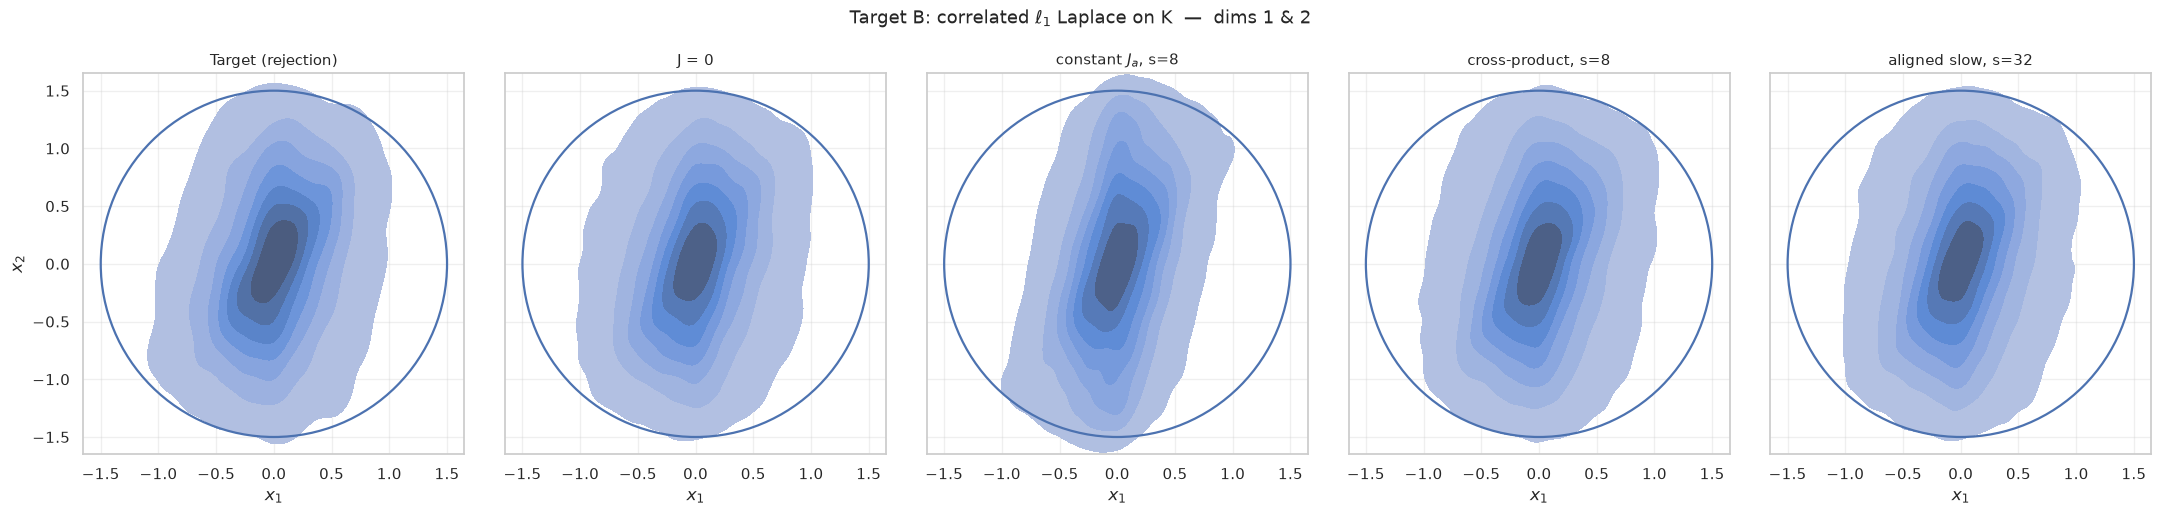

In [11]:
# 2-d marginals with the constraint circle drawn
for kind in TARGETS:
    panels = [("Target (rejection)", refs[kind])] + [
        (lab, RES[kind][lab]["X"].reshape(-1, d)) for lab in HEAD]
    fig, axes = plt.subplots(1, len(panels), figsize=(4.4 * len(panels), 4.7),
                             sharex=True, sharey=True)
    for ax, (name, X) in zip(axes, panels):
        sns.kdeplot(x=X[:, 0], y=X[:, 1], fill=True, levels=8, ax=ax, thresh=0.02)
        ax.add_patch(Circle((0, 0), R, edgecolor="b", facecolor="none", linewidth=1.6))
        ax.set_xlim(-1.1 * R, 1.1 * R); ax.set_ylim(-1.1 * R, 1.1 * R)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel("$x_1$", fontsize=12)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.3)
    axes[0].set_ylabel("$x_2$", fontsize=12)
    fig.suptitle(TARGETS[kind] + "  —  dims 1 & 2", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig("figures/ball_density_{}.pdf".format(kind), dpi=300, bbox_inches="tight")
    plt.show()

## Experiment 4 — the wall, where the constant field gives itself away

Projection deposits an atom on $\partial K$ that the continuous target does not have. How big it is
separates an admissible field from an inadmissible one: `const` drives $O(s)$ flux straight into the wall,
and the projection absorbs it.

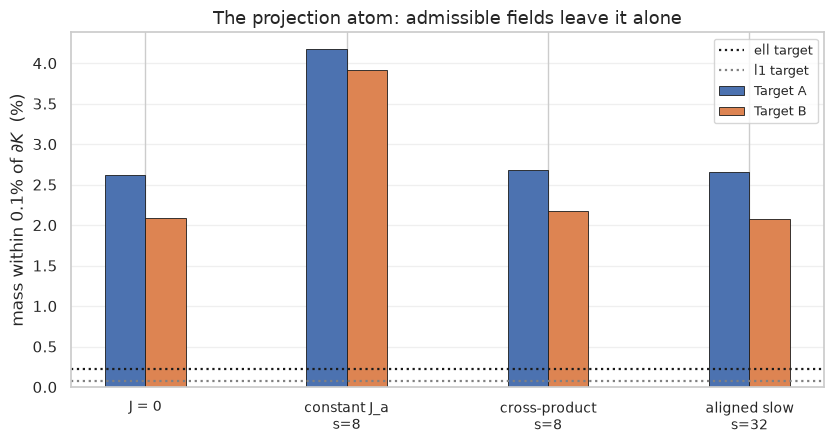

In [12]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
w = 0.2
labs = HEAD
for i, kind in enumerate(TARGETS):
    vals = [RES[kind][l]["bd"] * 100 for l in labs]
    ax.bar(np.arange(len(labs)) + (i - 0.5) * w, vals, width=w,
           label=TARGETS[kind].split(":")[0], edgecolor="k", linewidth=0.6)
for i, kind in enumerate(TARGETS):
    ax.axhline(on_boundary(refs[kind]) * 100, linestyle=":", linewidth=1.6,
               color=["k", "0.5"][i], label="{} target".format(kind))
ax.set_xticks(np.arange(len(labs)))
ax.set_xticklabels([l.replace("$", "").replace(", ", "\n") for l in labs], fontsize=10)
ax.set_ylabel(r"mass within 0.1% of $\partial K$  (%)", fontsize=12)
ax.set_title("The projection atom: admissible fields leave it alone", fontsize=13)
ax.grid(alpha=0.3, axis="y")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("figures/ball_boundary.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**The acceleration was there; it was being measured at the wrong moment, with a field that cannot be
aimed.** The previous run reported $W_1$ at 1500 iterations, where $J=0$ was still at $0.103$ against a
floor of $0.0134$ and falling by 20% every 300 iterations. Nothing had converged, so the table compared
positions in a race rather than stationary laws. At a horizon where $J=0$ does reach the floor, and with
the rotation aimed at the plane the target actually mixes slowly in, the picture is different.

### Aiming is most of the effect

Same field, same strength $s=16$, only the rotation plane changes:

| target | rotation plane | $\tau$ | speed-up vs $J=0$ |
|---|---|---|---|
| A (elliptical) | slow — two largest-variance eigenvectors | 1809 [1600, 2106] | **2.12× [1.79, 2.44]** |
| A | fast — two smallest | 3681 [3484, 3897] | 1.04× [0.96, 1.13] |
| A | arbitrary tridiagonal | 2950 [2809, 3094] | 1.30× [1.21, 1.40] |
| B ($\ell_1$) | slow | 1494 [1447, 1550] | **2.81× [2.68, 2.94]** |
| B | fast | 3684 [3528, 3866] | 1.14× [1.08, 1.20] |
| B | arbitrary tridiagonal | 3144 [2984, 3288] | 1.34× [1.26, 1.42] |

Pointed at the fast plane the field buys **nothing** — the interval covers 1 on target A. This is why the
cross-product field $s\,(x\times w)$ underperforms: it rotates about $x$, so its plane is whatever happens
to be perpendicular to the current position, never the one the geometry calls for.

### Head to head

| | $\tau$ | speed-up | stationary $W_1$ | max KS | mass on $\partial K$ |
|---|---|---|---|---|---|
| **A** $J=0$ | 3831 [3634, 4075] | — | 0.0137 [0.0122, 0.0155] | 0.0204 | 2.62% |
| A constant $J_a$, $s=8$ | never | — | 0.0463 [0.0458, 0.0470] | 0.0558 | **4.17%** |
| A cross-product, $s=8$ | 1428 [1356, 1506] | 2.68× [2.49, 2.91] | 0.0156 [0.0142, 0.0172] | 0.0243 | 2.68% |
| A aligned slow, $s=32$ | 1338 [1062, 1759] | 2.86× [2.15, 3.66] | 0.0155 [0.0142, 0.0167] | 0.0225 | 2.65% |
| A reference | — | — | 0.0136 (floor) | — | 0.22% |
| **B** $J=0$ | 4200 [4069, 4341] | — | 0.0116 [0.0104, 0.0128] | 0.0188 | 2.09% |
| B constant $J_a$, $s=8$ | never | — | 0.0485 [0.0478, 0.0494] | 0.0548 | **3.91%** |
| B cross-product, $s=8$ | 1528 [1416, 1669] | 2.75× [2.50, 2.99] | 0.0144 [0.0139, 0.0149] | 0.0231 | 2.17% |
| **B aligned slow, $s=32$** | 934 [822, 1081] | **4.49× [3.85, 5.14]** | 0.0124 [0.0118, 0.0130] | 0.0208 | 2.08% |
| B reference | — | — | 0.0118 (floor) | — | 0.08% |

On target B the aligned field dominates outright: **4.49× faster and closer to the floor at stationarity**
than the cross-product field (0.0124 against 0.0144). On target A the two overlap at $s=32$; pushing to
$s=64$ gives 3.77× [2.71, 5.14] but costs accuracy (0.0176), so $s=32$ is the better setting there.

### The cross-product field saturates; the aimable one does not

| speed-up | $s=4$ | $s=8$ | $s=16$ | $s=32$ | $s=64$ |
|---|---|---|---|---|---|
| A cross-product | 1.92× | 2.68× | 1.35× [0.78, 2.93] | — | — |
| A aligned slow | — | 1.75× | 2.12× | 2.86× | 3.77× |
| B cross-product | 2.10× | 2.75× | never reaches the threshold | — | — |
| B aligned slow | — | 1.50× | 2.81× | **4.49×** | 1.67× [1.02, 3.44] |

The cross-product field peaks near $s=8$ and then breaks: at $s=16$ its stationary $W_1$ is 0.0204 on A and
0.0269 on B, two to three times the floor. The aligned field climbs monotonically to $s=32$ because the
circulation stays in the plane that needs it rather than being spread over whatever plane the position
dictates.

### The correction term is the price of aiming

The cross-product field is divergence-free, which is why the earlier notebook could drop
$\nabla\!\cdot J$. The aimable field is not: $\nabla\!\cdot J_s=-\tfrac{s}{R^2}(d-2)Ax$, with mean norm
4.16 on $\partial K$ at $s=8$, and it must be carried. The closed form agrees with autograd to
$8.9\times10^{-16}$. Both fields put zero flux through the wall ($\lVert J\nu\rVert\sim10^{-16}$), and the
three fields have comparable operator norm there, so the comparison at equal $s$ is a fair one.

### The wall condition still separates admissible from inadmissible

The constant $J_a$ has $\lVert J_a\nu\rVert\approx8.9$ on $\partial K$ — it drives $O(s)$ flux straight
into the wall — and it fails on every axis: it never reaches twice the floor, sits at 3.4-4.1× the floor
at stationarity, and roughly doubles the projection atom (4.17% and 3.91% against $J=0$'s 2.62% and 2.09%,
target 0.22% and 0.08%). Admissibility is not optional, and aiming is what you do *within* the admissible
class.

### What is still shaky

$\tau$ is a last-crossing statistic and stays unstable at the largest strengths: A cross-product $s=16$
gives 2838 [1284, 4820] and B aligned $s=64$ gives 2509 [1234, 4128], intervals spanning a factor of three
to four, because a single replica's curve pokes back above threshold late in the run. Those two cells rank
nothing. Every cell quoted as a result above has an interval narrower than 1.4×.